In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from matplotlib import cm
from collections import deque

$\LARGE Edge\ Detection$

$Finite\ Difference\ Filters$

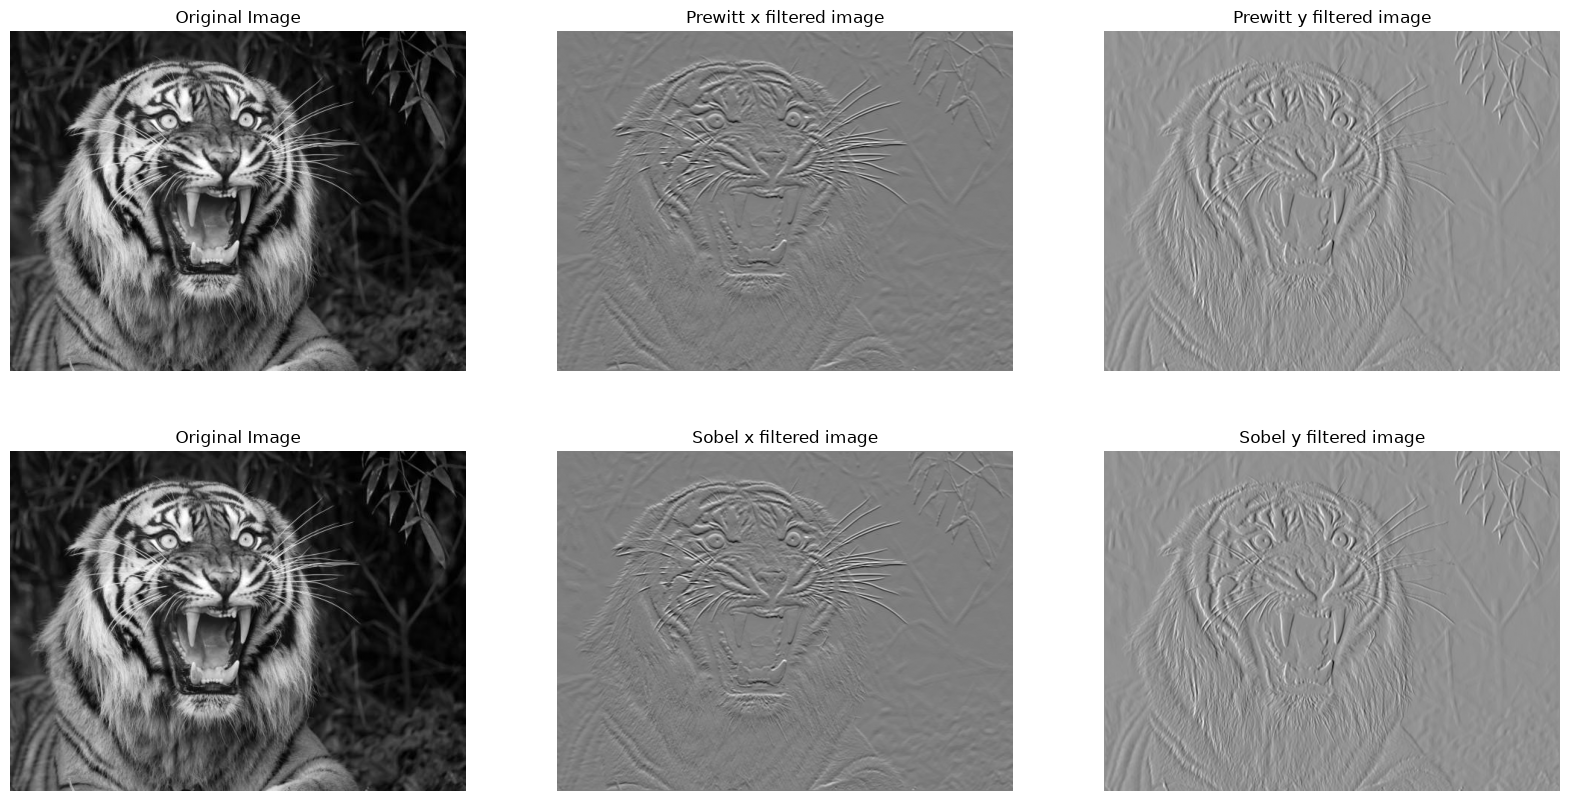

In [3]:
im = cv.imread('images/Tiger.jpg', cv.IMREAD_GRAYSCALE)
assert im is not None

#Prewitt filters
prewitt_x = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])
prewitt_y = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])

#Sobel filters
sobel_x = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
sobel_y = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])

prewitt_filtered_x = cv.filter2D(im, cv.CV_32F, prewitt_x)
prewitt_filtered_y = cv.filter2D(im, cv.CV_32F, prewitt_y)

sobel_filtered_x = cv.filter2D(im, cv.CV_32F, sobel_x)
sobel_filtered_y = cv.filter2D(im, cv.CV_32F, sobel_y)

#Normalizing
prewitt_filtered_x = cv.normalize(prewitt_filtered_x, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)
prewitt_filtered_y = cv.normalize(prewitt_filtered_y, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)
sobel_filtered_x = cv.normalize(sobel_filtered_x, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)
sobel_filtered_y = cv.normalize(sobel_filtered_y, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)

fig, ax = plt.subplots(2, 3, figsize = (20, 10))

ax[0, 0].imshow(im, cmap='gray')
ax[0, 0].set_title('Original Image')

ax[1, 0].imshow(im, cmap='gray')
ax[1, 0].set_title('Original Image')

ax[0, 1].imshow(prewitt_filtered_x, cmap='gray')
ax[0, 1].set_title('Prewitt x filtered image')

ax[0, 2].imshow(prewitt_filtered_y, cmap='gray')
ax[0, 2].set_title('Prewitt y filtered image')

ax[1, 1].imshow(sobel_filtered_x, cmap='gray')
ax[1, 1].set_title('Sobel x filtered image')

ax[1, 2].imshow(sobel_filtered_y, cmap='gray')
ax[1, 2].set_title('Sobel y filtered image')

for a in ax.ravel():
    a.axis('off')

plt.show()


$Derivatives\ of\ Gaussian\ Filters$

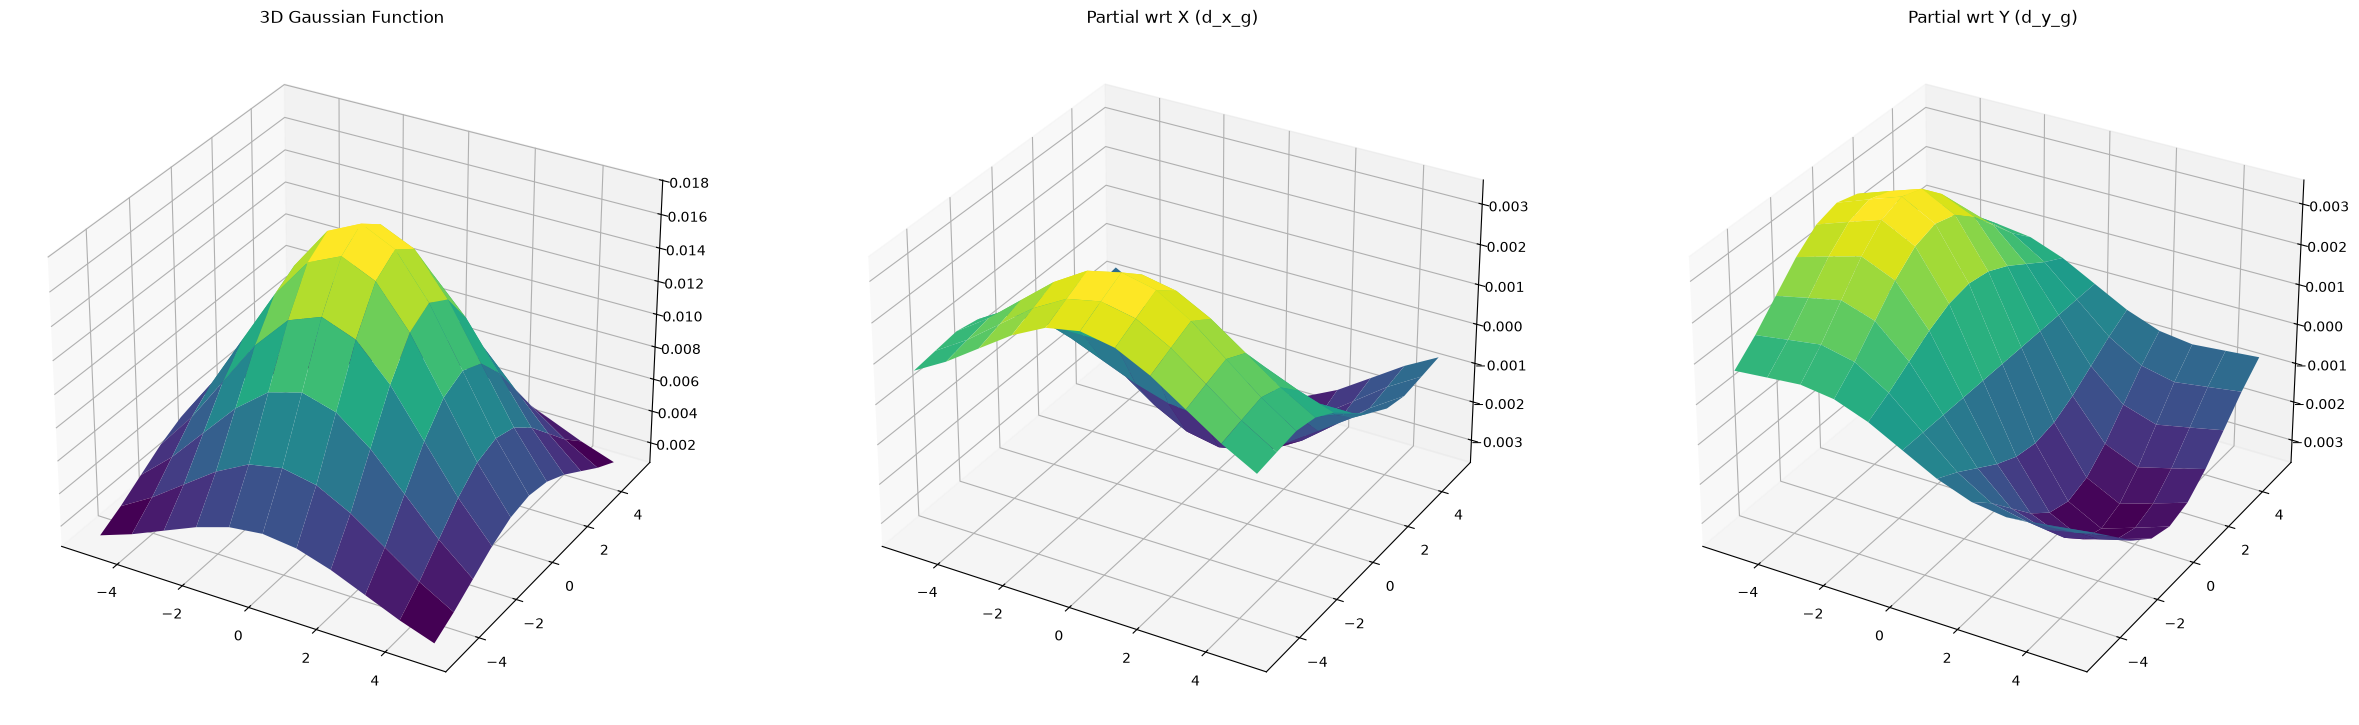

In [4]:
#Gaussian function
sigma = 3.0
x = np.arange(-5, 5.1, 1)
y = np.arange(-5, 5.1, 1)
x, y = np.meshgrid(x, y)

g_xy = (1/(2*np.pi*sigma**2)) * np.exp(-(x**2 + y**2)/(2*sigma**2))

d_x_g, d_y_g = np.gradient(g_xy)

fig, ax = plt.subplots(1, 3, figsize=(30, 10), subplot_kw={'projection': '3d'})

ax[0].plot_surface(x, y, g_xy, cmap='viridis')
ax[0].set_title('3D Gaussian Function')

ax[1].plot_surface(x, y, d_x_g, cmap='viridis')
ax[1].set_title('Partial wrt X (d_x_g)')

ax[2].plot_surface(x, y, d_y_g, cmap='viridis')
ax[2].set_title('Partial wrt Y (d_y_g)')

plt.show()



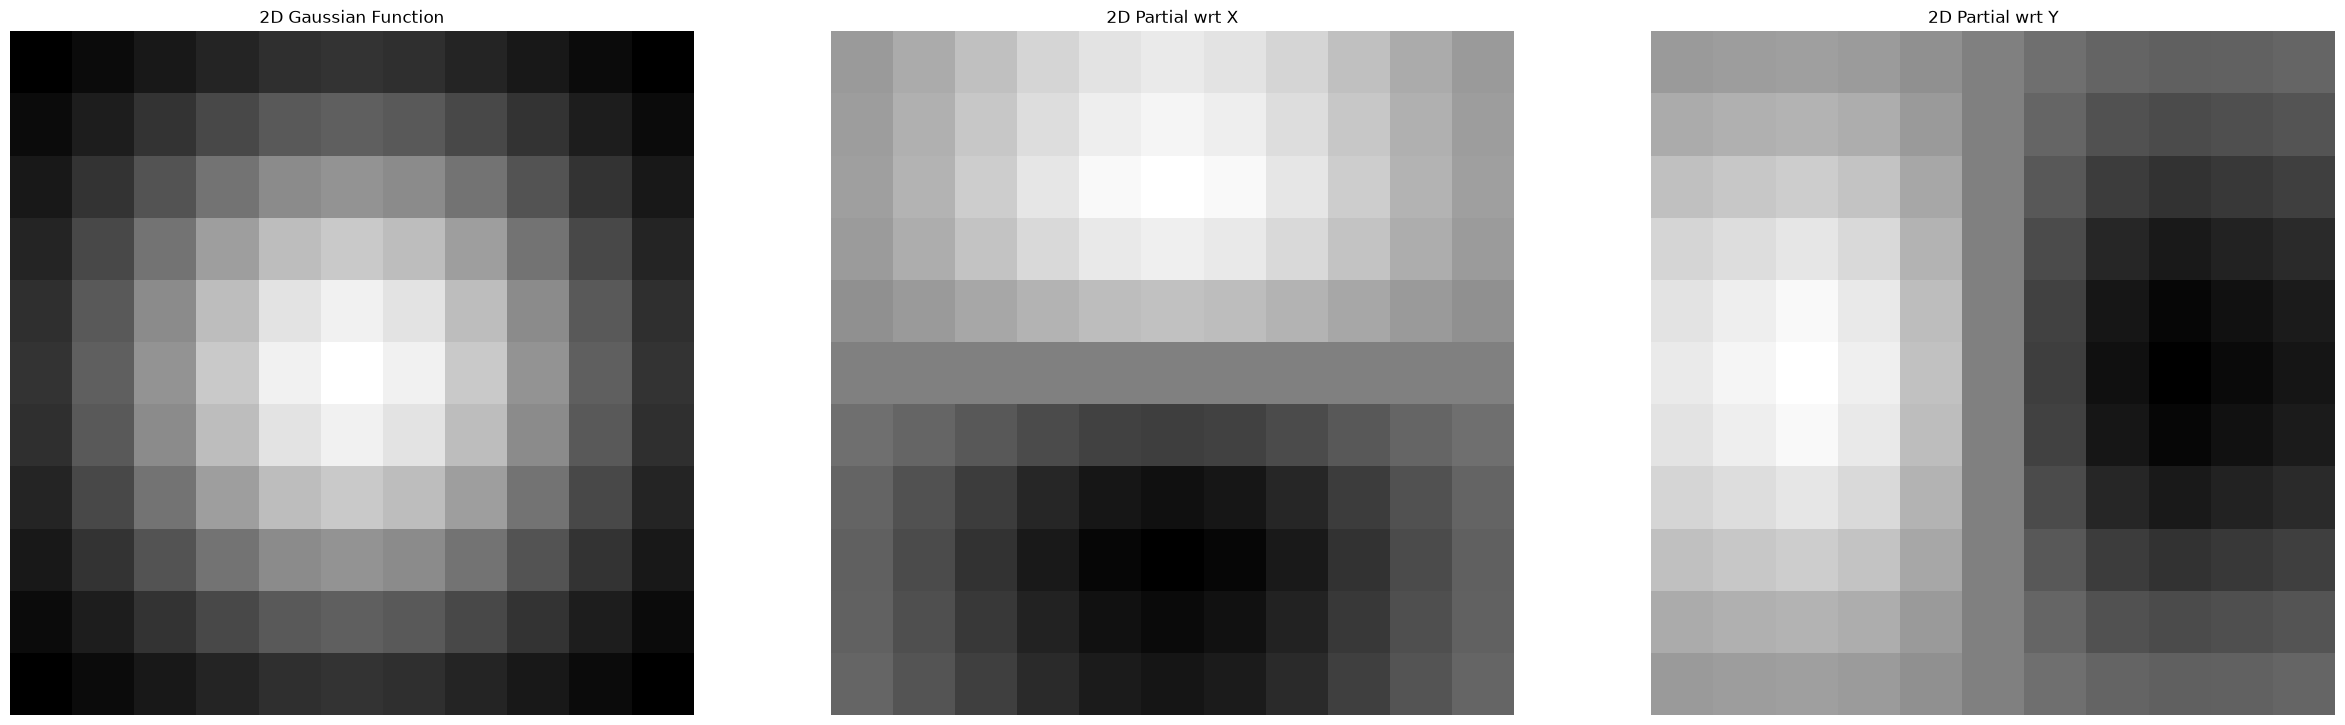

In [5]:
fig, ax = plt.subplots(1, 3, figsize = (30, 10))

ax[0].imshow(g_xy, cmap='gray')
ax[0].set_title('2D Gaussian Function')

ax[1].imshow(d_x_g, cmap='gray')
ax[1].set_title('2D Partial wrt X')

ax[2].imshow(d_y_g, cmap='gray')
ax[2].set_title('2D Partial wrt Y')

for a in ax:
    a.axis('off')

plt.show()



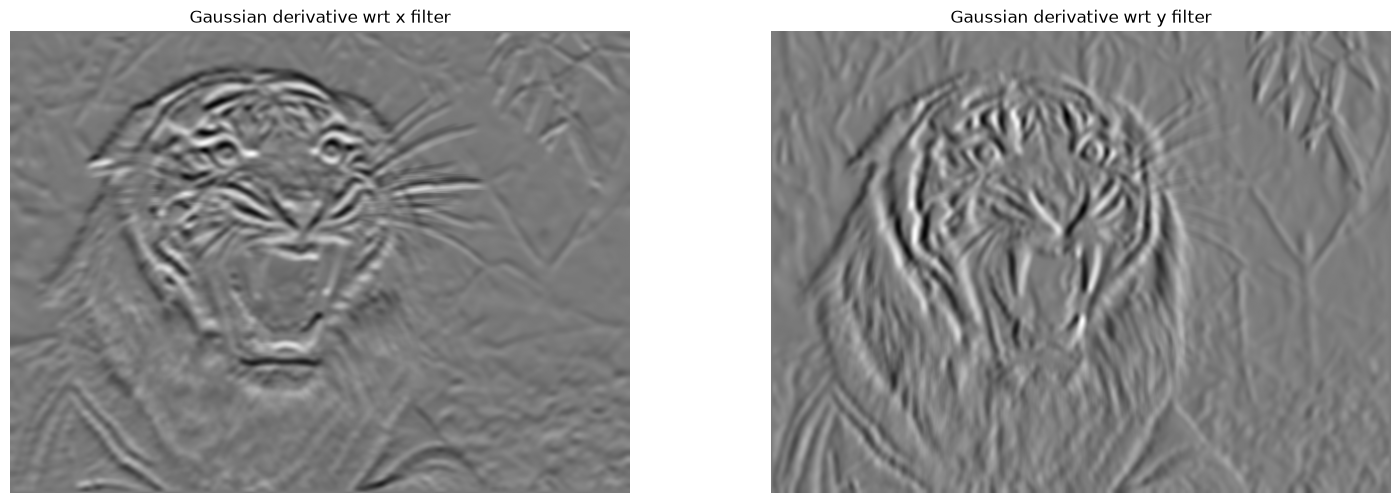

In [6]:
#Applying filters
im_gauss_x = cv.filter2D(im, cv.CV_32F, d_x_g)
im_gauss_y = cv.filter2D(im, cv.CV_32F, d_y_g)

#Normalizing
im_gauss_x = cv.normalize(im_gauss_x, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U) 
im_gauss_y = cv.normalize(im_gauss_y, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)

fig, ax = plt.subplots(1, 2, figsize = (18,6))
ax[0].imshow(im_gauss_x, cmap='gray')
ax[0].set_title('Gaussian derivative wrt x filter')

ax[1].imshow(im_gauss_y, cmap='gray')
ax[1].set_title('Gaussian derivative wrt y filter')

for a in ax:
    a.axis('off')

plt.show()





$Canny\ Edge\ Detector$

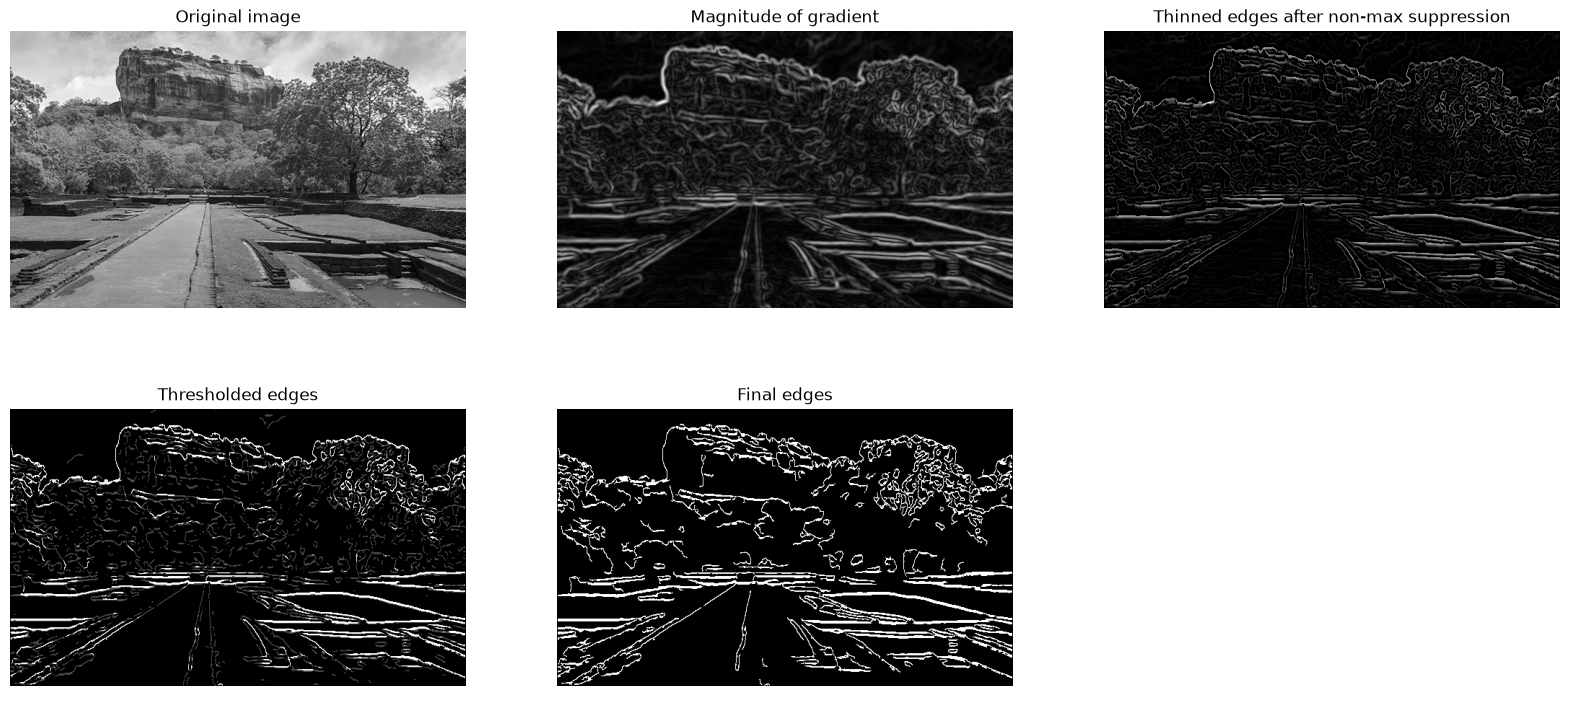

In [7]:
#Loaging the image
im_new = cv.imread('images/sigiriya.jpg', cv.IMREAD_GRAYSCALE)
assert im_new is not None

sigma = 2
x = np.arange(-5, 5.1, 1) 
y = np.arange(-5, 5.1, 1)

x, y = np.meshgrid(x, y) 

# Gaussian function and derivatives
g_xy = (1/(2*np.pi*sigma**2)) * np.exp(-(x**2 + y**2)/(2*sigma**2))
d_x_g, d_y_g = np.gradient(g_xy)

#Filtering the image with derivative of Gaussian
im_new_d_gaus_x = cv.filter2D(im_new, cv.CV_64F, d_x_g)
im_new_d_gaus_y = cv.filter2D(im_new, cv.CV_64F, d_y_g)

#Computing the magnitude of the gradient
im_mag = np.sqrt(im_new_d_gaus_x**2 + im_new_d_gaus_y**2)

#Computing the orientation of the gradient
im_orient = np.arctan2(im_new_d_gaus_y, im_new_d_gaus_x) * (180 / np.pi)

#Normalizing
im_mag_norm = cv.normalize(im_mag, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)

#Non maximum suppression function
def NMS(magnitude_img, angle_img):

    #Creating a blank image to contain the values
    thinned_edges = np.zeros_like(magnitude_img)

    #Number of rows and columns of the image
    rows, columns = np.shape(magnitude_img)

    #Iterating through the image
    #The reason for the range is we are not going thorugh the most outer pixels because they lack one neighbour because of that we start iteration from the immediate inner pixels
    for i in range(1, rows-1): 
        for j in range(1, columns-1):

            magnitude = magnitude_img[i, j]
            angle = angle_img[i, j]

            #Since we consider the pixels along the edge the direction and the opposite direction does not matter so we convert the angles to 0 to 180
            if angle < 0:
                angle += 180

            #And here since we are in the discrete world we quantize the angle values like this

            #0 degrees
            if (0 <= angle < 22.5) or (157.5 <= angle <= 180):

                #Declaring the neighbours
                q = magnitude_img[i + 1, j]
                r = magnitude_img[i + 1, j]

            #45 degrees
            elif 22.5 <= angle < 67.5:

                #Declaring the neighbours
                q = magnitude_img[i - 1, j - 1]
                r = magnitude_img[i + 1, j + 1]

            #90 dgrees
            elif 67.5 <= angle < 112.5:

                #Declaring the neighbours
                q = magnitude_img[i , j + 1]
                r = magnitude_img[i , j - 1]

            #135 degrees
            elif 112.5 <= angle < 157.5:

                #Declaring the neighbours
                q = magnitude_img[i + 1, j - 1]
                r = magnitude_img[i - 1, j + 1]


            #Non Maximum Supression
            if (magnitude >= q) and (magnitude >= r) :
                thinned_edges[i, j] = magnitude
            else:
                thinned_edges[i, j] = 0

    return thinned_edges

#Calling the Non Maximum supression
im_nms = NMS(im_mag_norm, im_orient)

#Double Thresholding
#Thresholds
high_threshold = 80
low_threshold = 40

#Edge intensity declaration
strong = 255
weak = 75
non_edge = 0

#Initial blank image
im_thresh = np.zeros_like(im_nms)

#Choosing the points 
high = im_nms >= high_threshold
low = (im_nms >= low_threshold) & (im_nms < high_threshold)

#Assigning values
im_thresh[high] = strong
im_thresh[low] = weak

#Linking function
def linking(thresholded_img, strong = 255, weak = 75):

    #Rows and columns
    rows, columns = np.shape(thresholded_img)

    #Creating blank image for the final edges
    edges = np.zeros_like(thresholded_img)

    #Creating a queue to store strong and connected pixels
    queue = deque()

    #Finding all strong pixels locations
    strong_pixels = np.argwhere(thresholded_img == strong)

    #Adding those strong pixels to the final image and the queue
    for i, j in strong_pixels:
        edges[i, j] = strong
        queue.append((i, j))

    #Defining the 8 neighbours of a single pixel
    neighbours = [
        (-1, -1), (-1, 0), (-1, 1),
        ( 0, -1),          ( 0, 1),
        ( 1, -1), ( 1, 0), ( 1, 1) 
    ]

    #Iterating until the queue is empty
    while queue:

        #Popping the leftmost element (FIFO)
        i, j = queue.popleft()

        #Going through the neighbours
        for di, dj in neighbours:
            ni = di + i
            nj = dj + j

            #Checking the image boundaries
            if (0 <= ni < rows) and (0 <= nj < columns) :

                #If neighbouring pixel is weak then it is connected
                if (thresholded_img[ni, nj] == weak) & (edges[ni, nj] == 0):

                    #So keep it
                    edges[ni, nj] = strong

                    #Add to the queue
                    queue.append((ni, nj))

    return edges

#Calling the linking function
im_edgs = linking(im_thresh, strong, weak)

fig, ax = plt.subplots(2, 3, figsize = (20, 9))
ax[0, 0].imshow(im_new, cmap = 'grey', vmin = 0, vmax = 255)
ax[0, 0].set_title("Original image")

ax[0, 1].imshow(im_mag_norm, cmap = 'grey', vmin = 0, vmax = 255)
ax[0, 1].set_title("Magnitude of gradient")

ax[0, 2].imshow(im_nms, cmap = 'grey', vmin = 0, vmax = 255)
ax[0, 2].set_title("Thinned edges after non-max suppression")

ax[1, 0].imshow(im_thresh, cmap = 'grey', vmin = 0, vmax = 255)
ax[1, 0].set_title("Thresholded edges")

ax[1, 1].imshow(im_edgs, cmap = 'grey', vmin = 0, vmax = 255)
ax[1, 1].set_title("Final edges")

for a in ax.ravel():
    a.axis('off')

plt.show()


$\LARGE Corner\ Detection$

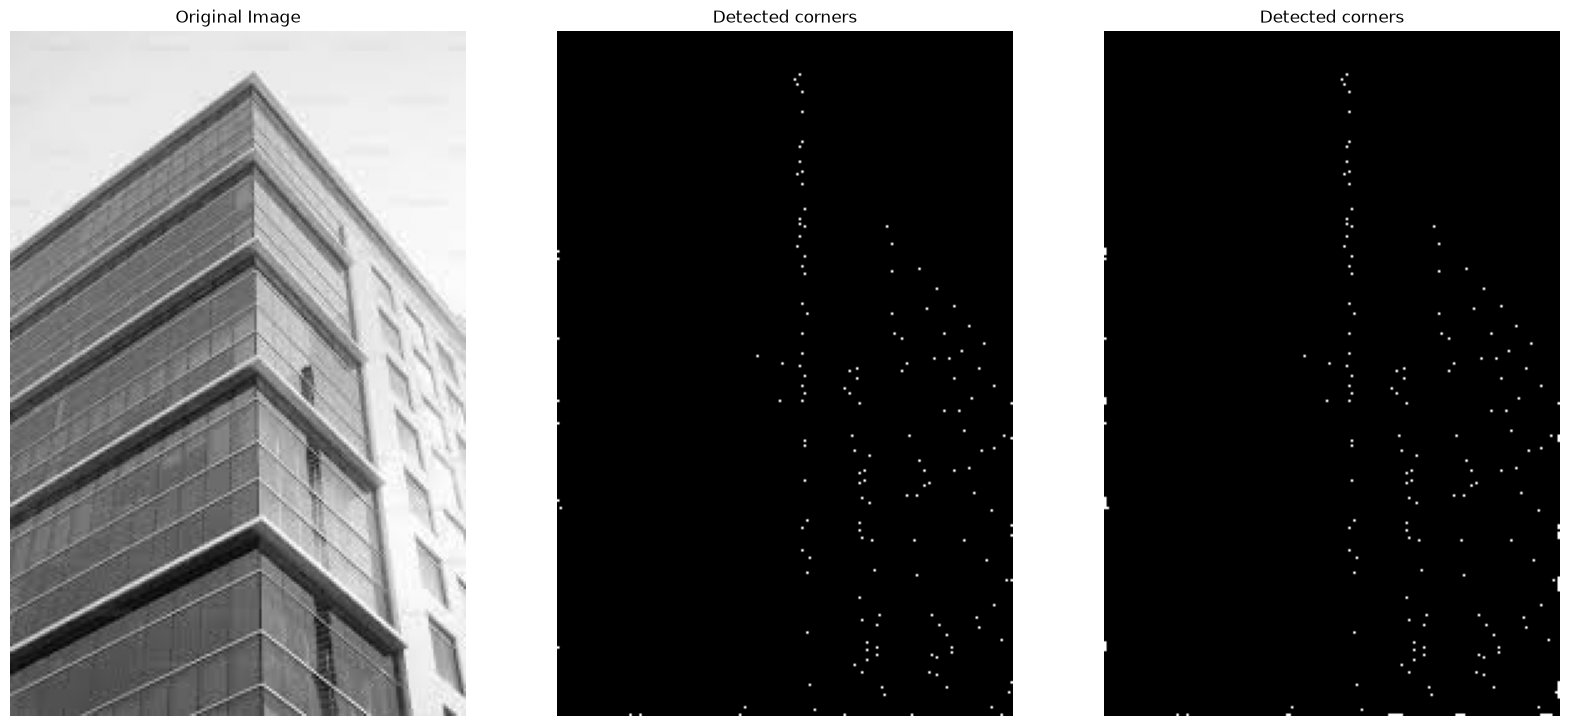

In [69]:
#Loading the sample image
im = cv.imread('images/building.jpg', cv.IMREAD_GRAYSCALE)
assert im is not None

#Derivative filters
#Prewitt filters
prewitt_x = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])
prewitt_y = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])

#Sobel filters
sobel_x = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
sobel_y = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])

#Calculating the first ordre partial derivatives of the image
I_x_p = cv.filter2D(im, cv.CV_64F, prewitt_x)
I_y_p = cv.filter2D(im, cv.CV_64F, prewitt_y)
I_x_s = cv.filter2D(im, cv.CV_64F, sobel_x)
I_y_s = cv.filter2D(im, cv.CV_64F, sobel_y)

#Getting the second order partial derivatives
I_x_x_p = np.multiply(I_x_p, I_x_p)
I_x_y_p = np.multiply(I_x_p, I_y_p)
I_y_y_p = np.multiply(I_y_p, I_y_p)

I_x_x_s = np.multiply(I_x_s, I_x_s)
I_x_y_s = np.multiply(I_x_s, I_y_s)
I_y_y_s = np.multiply(I_y_s, I_y_s)

#Appliyinh gaussian blur window at each pixel
I_x_x_p_gauss = cv.GaussianBlur(I_x_x_p, (3, 3), 1)
I_x_y_p_gauss = cv.GaussianBlur(I_x_y_p, (3, 3), 1)
I_y_y_p_gauss = cv.GaussianBlur(I_y_y_p, (3, 3), 1)

I_x_x_s_gauss = cv.GaussianBlur(I_x_x_s, (3, 3), 1)
I_x_y_s_gauss = cv.GaussianBlur(I_x_y_s, (3, 3), 1)
I_y_y_s_gauss = cv.GaussianBlur(I_y_y_s, (3, 3), 1)

#To calculate Corner Response Function
det_M = np.multiply(I_x_x_s_gauss, I_y_y_s_gauss) - np.multiply(I_x_y_s_gauss, I_x_y_s_gauss)
trace_M = I_x_x_s_gauss + I_y_y_s_gauss

alpha = 0.04

R = det_M - alpha * np.multiply(trace_M, trace_M)

#Thresholding
im_thresh = np.copy(R)

threshold = 0.01 * R.max()

low = R < threshold

im_thresh[low] = 0

#Non maximum supression from scratch
def NMS_corners(thresholded_image):

    #Blank image
    detected_corners = np.copy(thresholded_image)

    #Image dimensions 
    rows, columns = np.shape(thresholded_image)

    #Declaring neighbours
    neighbours = [
            (-1, -1), (-1, 0), (-1, 1),
            ( 0, -1),          ( 0, 1),
            ( 1, -1), ( 1, 0), ( 1, 1) 
        ]

    #Iterating through the image
    for i in range(1, rows-1):
        for j in range(1, columns-1):

            magnitude = thresholded_image[i, j]
            is_local_max = True #Assuming this pixel is the local maximum

            #No need to check if the magnitude is 0
            if magnitude == 0:
                continue

            #Going through the neighbours
            for di, dj in neighbours:
                ni = di + i
                nj = dj + j

                magnitude_neigbour = thresholded_image[ni, nj]

                if magnitude_neigbour > magnitude:
                    is_local_max = False
                    break

            if not is_local_max:
                detected_corners[i, j] = 0

    #Now the remaining pixels are the points where only corners are detected
    high = detected_corners > 0

    #Increasing there intensities to max
    detected_corners[high] = 255

    return detected_corners

corners_scratch = NMS_corners(im_thresh)

#Non Maximum Supression from OpneCV
#Dilate the thresholded image (scans a 3x3 window and grabs the max)
im_thresh_dilated = cv.dilate(im_thresh, np.ones((3,3), np.uint8))

#A pixel is a true corner if its original value matches the dilated value
is_local_max = (im_thresh == im_thresh_dilated) & (im_thresh > 0)

#Blank image to store corners
corners_openCV = np.zeros_like(im_thresh_dilated)

#Assigning values
corners_openCV[is_local_max] = 255

fig, ax = plt.subplots(1, 3, figsize = (20, 15))
ax[0].imshow(im, cmap = 'gray')
ax[0].set_title("Original Image")

ax[1].imshow(corners_openCV, cmap = 'gray')
ax[1].set_title("Detected corners")

ax[2].imshow(corners_scratch, cmap = 'gray')
ax[2].set_title("Detected corners")


for a in ax:
    a.axis('off')


plt.show()

$\LARGE Blob\ Detection$

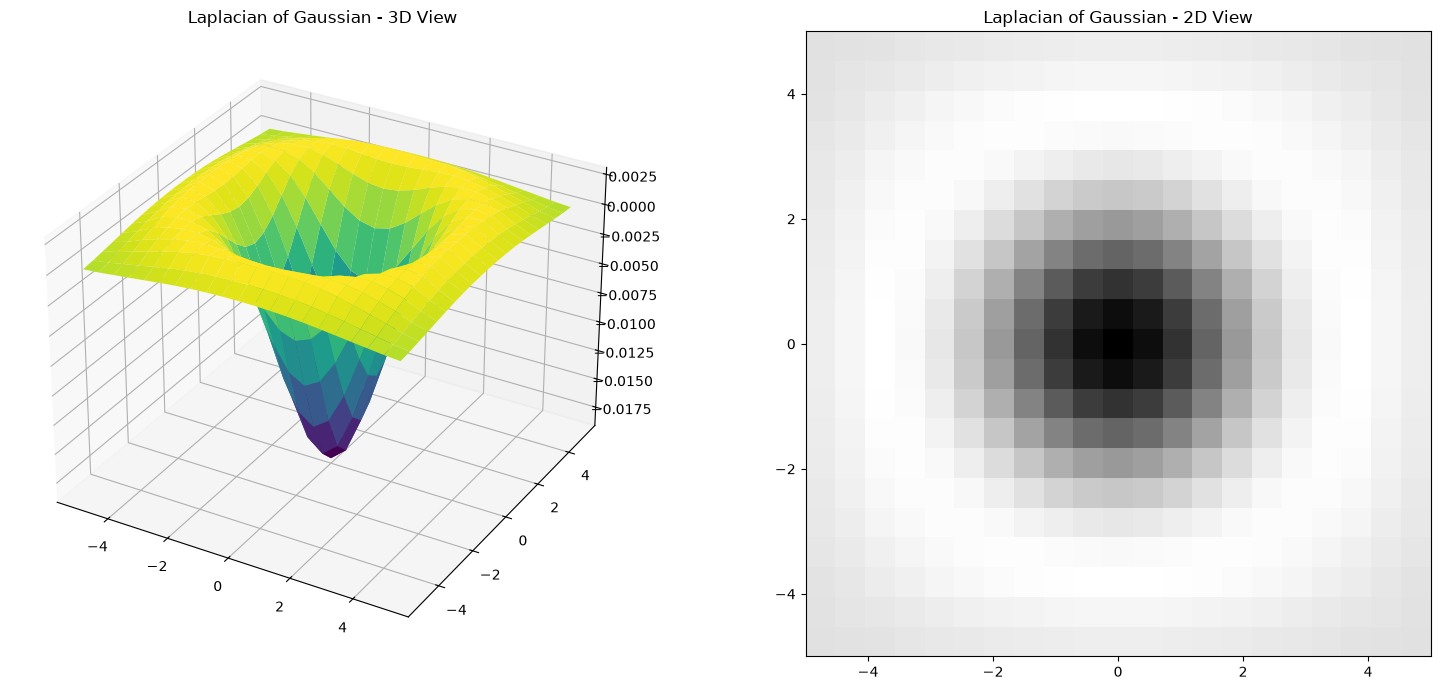

In [9]:
#Blob filter

#Creating gaussian function
sigma = 2.0
x = np.arange(-5, 5.1, 0.5)
y = np.arange(-5, 5.1, 0.5)
x, y = np.meshgrid(x, y) 

g_xy = (1/(2*np.pi*sigma**2)) * np.exp(-(x**2 + y**2)/(2*sigma**2))

#Laplacian of gaussian
# first derivatives
gx = np.gradient(g_xy, axis=1)
gy = np.gradient(g_xy, axis=0)

# second derivatives
g_xx = np.gradient(gx, axis=1)
g_yy = np.gradient(gy, axis=0)

laplacian_of_gaussian = (sigma**2)*(g_xx + g_yy)

# Create figure
fig = plt.figure(figsize=(16, 7))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface( x, y, laplacian_of_gaussian, cmap='viridis')
ax1.set_title('Laplacian of Gaussian - 3D View')

ax2 = fig.add_subplot(1, 2, 2)

# Normalize only for displaying as an image
log_display = cv.normalize(laplacian_of_gaussian, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)

ax2.imshow(log_display, cmap='gray', extent=[-5, 5, -5, 5])
ax2.set_title('Laplacian of Gaussian - 2D View')

plt.tight_layout()
plt.show()



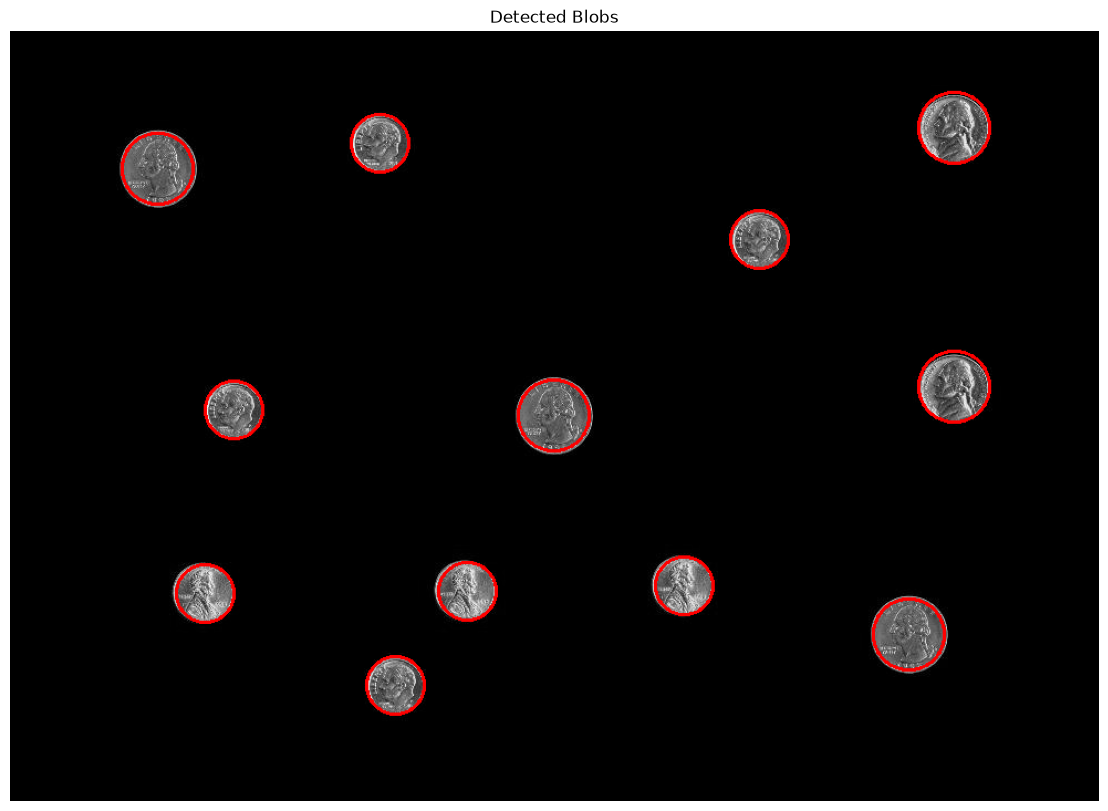

In [ ]:
#Loading the sample image
im = cv.imread('images/Coins.jpeg', cv.IMREAD_GRAYSCALE)
assert im is not None # Keep this, it's a great habit!

# Define how many scale levels you want to test
sigma_list = [1.6 * (1.25 ** i) for i in range(10,15)]

# Blank 3D space to store images
scale_space = np.zeros((im.shape[0], im.shape[1], len(sigma_list)), dtype=np.float64)

#Looping through the sigma values to store the image
for layer_index, sigma in enumerate(sigma_list):

    k = int(3*sigma)

    x = np.arange(-k, k + 1)
    y = np.arange(-k, k + 1)
    x, y = np.meshgrid(x, y) 

    g_xy = (1/(2*np.pi*sigma**2)) * np.exp(-(x**2 + y**2)/(2*sigma**2))

    #Laplacian of gaussian
    # first derivatives
    gx = np.gradient(g_xy, axis=1)
    gy = np.gradient(g_xy, axis=0)

    # second derivatives
    g_xx = np.gradient(gx, axis=1)
    g_yy = np.gradient(gy, axis=0)

    laplacian_of_gaussian = (sigma**2)*(g_xx + g_yy)

    #Applying the filter to the image
    im_laplace = cv.filter2D(im, cv.CV_64F, laplacian_of_gaussian)

    #Storing the image
    scale_space[:, :, layer_index] = im_laplace

#3D non maximum supression
def NMS_3D (image_block):

    #Blank image_block
    block = np.zeros((image_block.shape[0], image_block.shape[1], image_block.shape[2]), dtype=np.float64)

    #Getting the dimensions of the block
    rows, columns, height = np.shape(image_block)

    #Neighbours
    neighbours = [
                (-1, -1, -1), (-1, 0, -1), (-1, 1, -1),
                ( 0, -1, -1), ( 0, 0, -1), ( 0, 1, -1),
                ( 1, -1, -1), ( 1, 0, -1), ( 1, 1, -1) 
            ,
                  
                (-1, -1, 0), (-1, 0, 0), (-1, 1, 0),
                ( 0, -1, 0),             ( 0, 1, 0),
                ( 1, -1, 0), ( 1, 0, 0), ( 1, 1, 0) 
            , 
                  
                (-1, -1, 1), (-1, 0, 1), (-1, 1, 1),
                ( 0, -1, 1), ( 0, 0, 1), ( 0, 1, 1),
                ( 1, -1, 1), ( 1, 0, 1), ( 1, 1, 1) 
            ]


    #Squaring the image block to remove the negative values
    squared_image_block = np.multiply(image_block, image_block)

    #Adding a threshold to avoid unnesssary calculations
    threshold = 0.3 * squared_image_block.max()

    for i in range(1, rows - 1):
        for j in range(1, columns - 1):
            for k in range(1, height - 1):


                magnitude = squared_image_block[i, j, k]
                local_max_coordinates = [i, j, k]
                is_local_max = True

                #Ignoring the loop when when the value is too weak
                if magnitude < threshold :
                    continue

                for di, dj, dk in neighbours:

                    ni = i + di
                    nj = j + dj
                    nk = k + dk

                    if magnitude < squared_image_block[ni, nj, nk]:
                        is_local_max = False
                        break

                #If the center survives save the point
                if is_local_max:
                    block[i, j, k] = 255

    return block

#Image block after NMS 
scale_space_nms = NMS_3D(scale_space)

#Getting the indices of the non suppressed points
non_zero_values = np.argwhere(scale_space_nms > 0)


#Scipy method to do the NMS
'''import scipy.ndimage as ndimage

# --- Replace your entire NMS_3D function with this ---

# 1. Square the block just like before to handle negative values
squared_space = np.square(scale_space)

# 2. The SciPy Cheat Code: This instantly slides a 3x3x3 window over the 
# entire block and replaces every pixel with the maximum value in its neighborhood.
local_max_space = ndimage.maximum_filter(squared_space, size=3)

# 3. Calculate your threshold
threshold = 0.2* squared_space.max()

# 4. The Final Check: A point is a true local maximum ONLY IF its original value 
# perfectly matches the maximum value found by the filter, AND it beats the threshold.
# This returns a 3D boolean array (True for blobs, False for background)
scale_space_nms = (squared_space == local_max_space) & (squared_space > threshold)

# --- Proceed directly to your drawing loop! ---

# Getting the indices of the non suppressed points
# (np.argwhere works perfectly with the boolean array)
non_zero_values = np.argwhere(scale_space_nms)'''

#Creating an image to draw colourd circles
im_with_blobs = cv.cvtColor(im, cv.COLOR_GRAY2BGR)

#Itarting through the non zero points to draw circles
for point in non_zero_values:

    #Format , (row, column, scale_index)
    y = point[0]
    x = point[1]
    scale_index = point[2]

    sigma = sigma_list[scale_index]

    #Radius
    radius = int(sigma * np.sqrt(2))

    #Drawing the circle
    cv.circle(im_with_blobs, (x, y), radius, (0, 0, 255), 2)

# Plot the final masterpiece
plt.figure(figsize=(15, 10))
plt.imshow(cv.cvtColor(im_with_blobs, cv.COLOR_BGR2RGB))
plt.title("Detected Blobs")
plt.axis('off')
plt.show()